In [1]:
import importlib, subprocess, sys
REQUIRED = {
    'diffusers': 'diffusers==0.31.0',
    'transformers': 'transformers==4.46.3',
    'accelerate': 'accelerate==1.0.1',
    'peft': 'peft==0.13.2',
    'bitsandbytes': 'bitsandbytes',
    'safetensors': 'safetensors',
    'huggingface_hub': 'huggingface-hub',
    'facenet_pytorch': 'facenet-pytorch',
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

In [2]:
import os, json, glob, shutil, time, random, math, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

PyTorch: 2.4.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 7.6 GB


In [3]:
LAB = Path(os.getcwd()).resolve()
if LAB.name != 'lab-8':
    cand = LAB / 'lab-8'
    if cand.exists():
        LAB = cand.resolve()
DATA = LAB / 'data'
ME_DIR = DATA / 'me'
FACES_DIR = DATA / 'faces_512'
LORA_DIR = LAB / 'runs' / 'lora_sd15_v2'
SAMPLES_DIR = LAB / 'samples'
RESULTS_PATH = LAB / 'results.json'

for p in [DATA, ME_DIR, FACES_DIR, LORA_DIR, SAMPLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

BASE_MODEL = 'runwayml/stable-diffusion-v1-5'
INSTANCE_TOKEN = 'ohwx'
GENDER = 'man'
INSTANCE_PROMPT = f'a close-up portrait photo of {INSTANCE_TOKEN} {GENDER}'

RESOLUTION = 512
LORA_RANK = 32
LR_UNET = 1e-4
LR_TEXT = 5e-5
MAX_TRAIN_STEPS = 2000
GRAD_ACCUM = 1
BATCH = 1
SAVE_EVERY = 1000

INFERENCE_STEPS = 35
GUIDANCE = 7.0
SEED = 42

print('LAB:', LAB)
print('device:', device)
print('instance prompt:', INSTANCE_PROMPT)

LAB: /mnt/data/itmo-cv/lab-8
device: cuda
instance prompt: a close-up portrait photo of ohwx man


## 1. Референсные фото

20 reference photos in /mnt/data/itmo-cv/lab-8/data/me


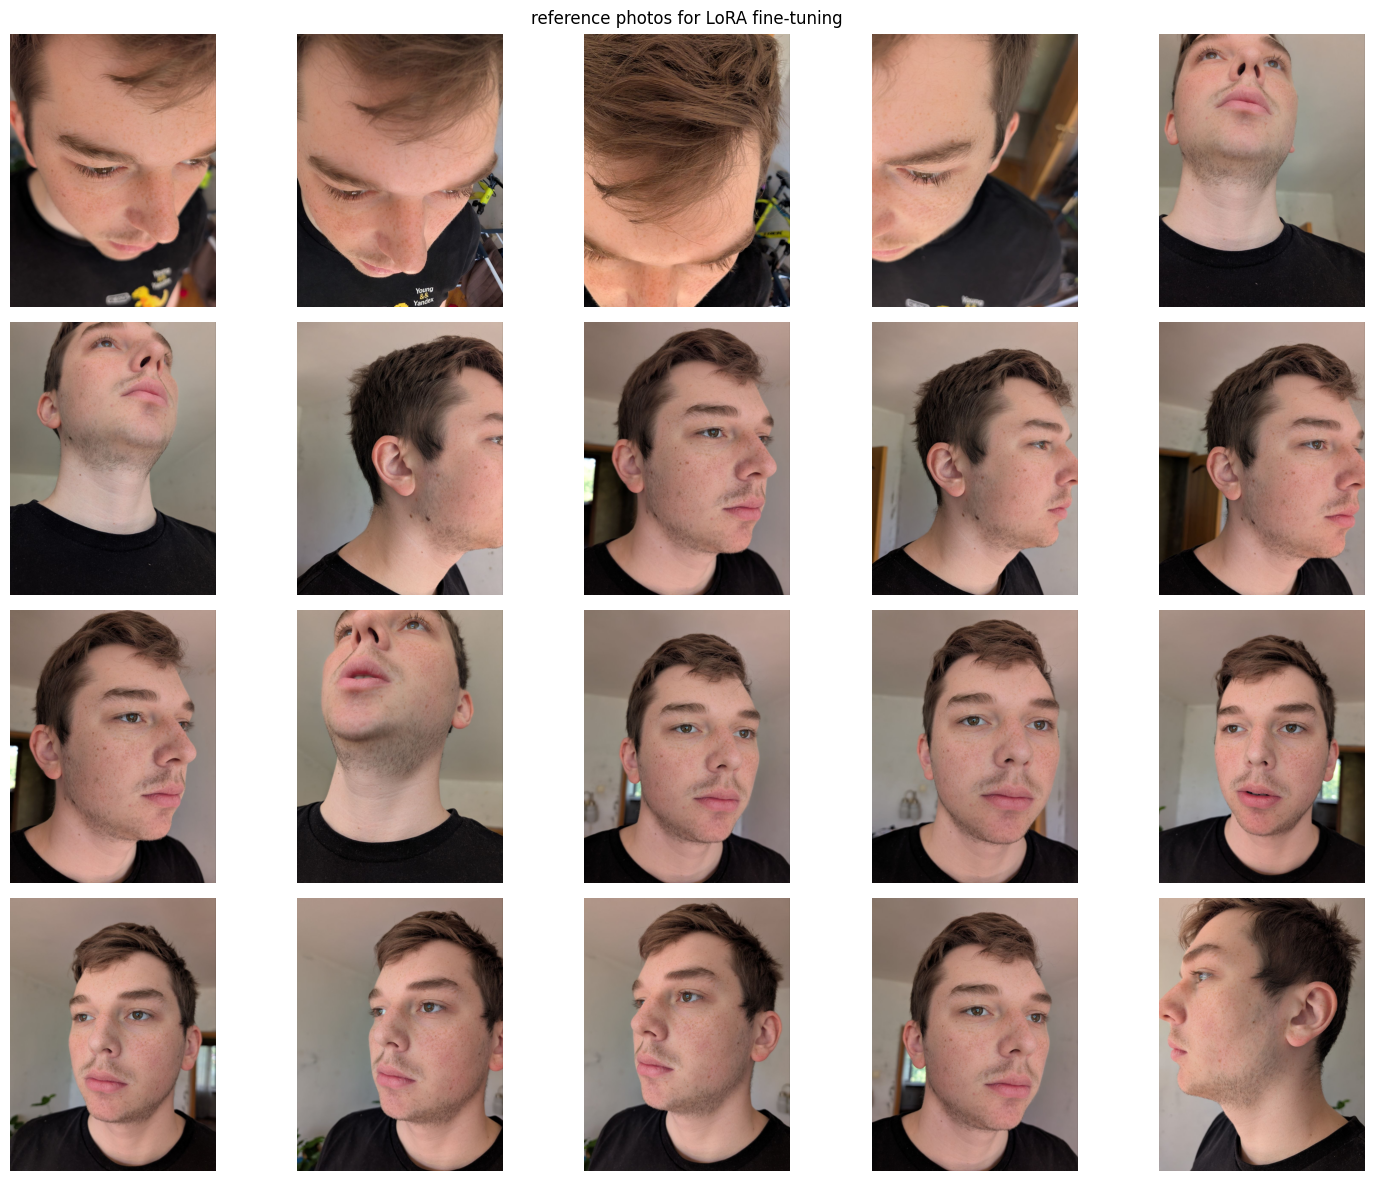

In [4]:
exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
me_imgs = sorted(sum([list(ME_DIR.glob(e)) for e in exts], []))
print(f'{len(me_imgs)} reference photos in {ME_DIR}')
if len(me_imgs) < 5:
    raise SystemExit(f'нужно минимум 5 (а лучше 12-15) фото в {ME_DIR}')

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, p in zip(axes.flat, me_imgs[:20]):
    ax.imshow(Image.open(p).convert('RGB'))
    ax.axis('off')
for ax in axes.flat[len(me_imgs):]:
    ax.axis('off')
plt.suptitle('reference photos for LoRA fine-tuning')
plt.tight_layout(); plt.show()

## 2. MTCNN tight face-crop

/mnt/data/itmo-cv/.venv/lib/python3.12/site-packages/facenet_pytorch/models/mtcnn.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(state_dict_pat

face-crop:   0%|          | 0/20 [00:00<?, ?it/s]

face-crop:   5%|▌         | 1/20 [00:00<00:06,  2.83it/s]

face-crop:  15%|█▌        | 3/20 [00:00<00:02,  7.12it/s]

face-crop:  25%|██▌       | 5/20 [00:00<00:01, 10.34it/s]

...

face-crop:  75%|███████▌  | 15/20 [00:01<00:00, 14.83it/s]

face-crop:  85%|████████▌ | 17/20 [00:01<00:00, 15.04it/s]

face-crop:  95%|█████████▌| 19/20 [00:01<00:00, 15.13it/s]

face-crop: 100%|██████████| 20/20 [00:01<00:00, 12.79it/s]

saved 15 face crops to /mnt/data/itmo-cv/lab-8/data/faces_512


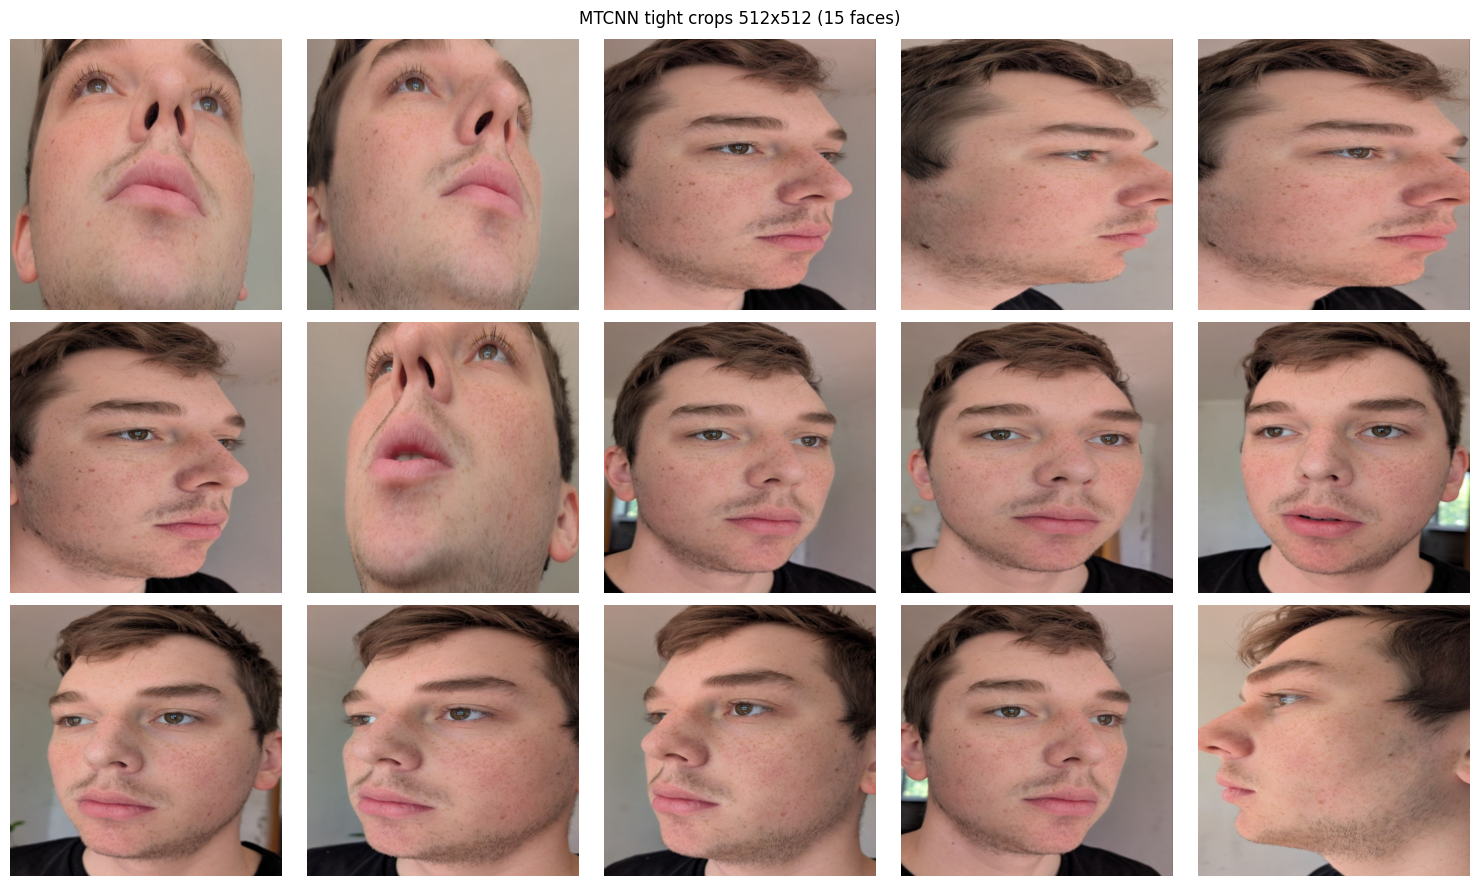

In [5]:
from facenet_pytorch import MTCNN

face_files = sorted(FACES_DIR.glob('*.jpg'))
if len(face_files) >= len(me_imgs):
    print(f'[skip] face crops already done: {len(face_files)}')
else:
    mtcnn = MTCNN(image_size=RESOLUTION, margin=80, select_largest=True, post_process=False, device=device)
    n_saved = 0
    for p in tqdm(me_imgs, desc='face-crop'):
        try:
            img = Image.open(p).convert('RGB')
            face = mtcnn(img)
        except Exception:
            continue
        if face is None:
            continue
        face_np = face.permute(1, 2, 0).byte().cpu().numpy()
        out = FACES_DIR / f'{n_saved:04d}.jpg'
        Image.fromarray(face_np).save(out, quality=95)
        n_saved += 1
    print(f'saved {n_saved} face crops to {FACES_DIR}')
    face_files = sorted(FACES_DIR.glob('*.jpg'))

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, p in zip(axes.flat, face_files[:15]):
    ax.imshow(Image.open(p))
    ax.axis('off')
for ax in axes.flat[len(face_files):]:
    ax.axis('off')
plt.suptitle(f'MTCNN tight crops 512x512 ({len(face_files)} faces)')
plt.tight_layout(); plt.show()

## 3. SD 1.5 + LoRA (UNet + text encoder)

In [6]:
from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
import bitsandbytes as bnb

tokenizer = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder='text_encoder', torch_dtype=torch.float32).to(device)
vae = AutoencoderKL.from_pretrained(BASE_MODEL, subfolder='vae', torch_dtype=torch.float16).to(device)
unet = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder='unet', torch_dtype=torch.float32).to(device)
noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder='scheduler')

for p in vae.parameters(): p.requires_grad_(False)
for p in unet.parameters(): p.requires_grad_(False)
for p in text_encoder.parameters(): p.requires_grad_(False)

unet.enable_gradient_checkpointing()
text_encoder.gradient_checkpointing_enable()

unet_lora = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK,
    target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
    lora_dropout=0.0, bias='none',
)
text_lora = LoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj'],
    lora_dropout=0.0, bias='none',
)
unet = get_peft_model(unet, unet_lora)
text_encoder = get_peft_model(text_encoder, text_lora)
unet.print_trainable_parameters()
text_encoder.print_trainable_parameters()

trainable params: 6,377,472 || all params: 865,898,436 || trainable%: 0.7365
trainable params: 2,359,296 || all params: 125,419,776 || trainable%: 1.8811


## 4. Dataset из face-crops

In [7]:
INSTANCE_VARIANTS = [
    f'a close-up portrait photo of {INSTANCE_TOKEN} {GENDER}',
    f'a photo of {INSTANCE_TOKEN} {GENDER}',
    f'a portrait of {INSTANCE_TOKEN} {GENDER}',
    f'a headshot of {INSTANCE_TOKEN} {GENDER}',
    f'a face photo of {INSTANCE_TOKEN} {GENDER}',
]


class FaceLoRADataset(Dataset):
    def __init__(self, image_paths, prompts, tokenizer, resolution=512):
        self.paths = image_paths
        self.prompts = prompts
        self.tokenizer = tokenizer
        self.tf = transforms.Compose([
            transforms.Resize(int(resolution * 1.1), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomCrop(resolution),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
    def __len__(self):
        return len(self.paths) * 200
    def __getitem__(self, i):
        p = self.paths[i % len(self.paths)]
        img = Image.open(p).convert('RGB')
        prompt = self.prompts[i % len(self.prompts)]
        ids = self.tokenizer(prompt, padding='max_length', max_length=self.tokenizer.model_max_length,
                             truncation=True, return_tensors='pt').input_ids[0]
        return {'pixel_values': self.tf(img), 'input_ids': ids}


train_ds = FaceLoRADataset(face_files, INSTANCE_VARIANTS, tokenizer, RESOLUTION)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
print('dataset:', len(train_ds), 'samples (with repeat), batch=', BATCH)

dataset: 3000 samples (with repeat), batch= 1


## 5. Тренировка LoRA (UNet + text encoder)

In [8]:
unet_state_path = LORA_DIR / 'unet_lora.safetensors'
text_state_path = LORA_DIR / 'text_lora.safetensors'
history_path = LORA_DIR / 'history.csv'

if unet_state_path.exists() and text_state_path.exists():
    print(f'[skip] LoRA already trained: {unet_state_path}')
    history = pd.read_csv(history_path).values.tolist() if history_path.exists() else []
else:
    trainable = [p for p in unet.parameters() if p.requires_grad] + \
                [p for p in text_encoder.parameters() if p.requires_grad]
    optimizer = bnb.optim.AdamW8bit([
        {'params': [p for p in unet.parameters() if p.requires_grad], 'lr': LR_UNET},
        {'params': [p for p in text_encoder.parameters() if p.requires_grad], 'lr': LR_TEXT},
    ], betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8)
    history = []
    step = 0
    t0 = time.time()
    pbar = tqdm(total=MAX_TRAIN_STEPS, desc='lora train')
    accum_loss = 0.0
    while step < MAX_TRAIN_STEPS:
        for batch in train_loader:
            pixel_values = batch['pixel_values'].to(device, dtype=torch.float16)
            input_ids = batch['input_ids'].to(device)

            with torch.no_grad():
                latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
            ids = input_ids.unsqueeze(0) if input_ids.dim() == 1 else input_ids
            encoder_hidden_states = text_encoder(ids)[0]

            noise = torch.randn_like(latents)
            bs = latents.size(0)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bs,), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                model_pred = unet(noisy_latents.float(), timesteps, encoder_hidden_states.float()).sample
                loss = F.mse_loss(model_pred.float(), noise.float())
            (loss / GRAD_ACCUM).backward()
            accum_loss += loss.item()

            if (step + 1) % GRAD_ACCUM == 0:
                optimizer.step()
                optimizer.zero_grad()

            step += 1
            if step % 25 == 0:
                avg = accum_loss / 25
                history.append([step, avg])
                pbar.set_postfix(loss=f'{avg:.4f}')
                accum_loss = 0.0
            pbar.update(1)
            if step % SAVE_EVERY == 0 or step >= MAX_TRAIN_STEPS:
                pd.DataFrame(history, columns=['step', 'loss']).to_csv(history_path, index=False)
            if step >= MAX_TRAIN_STEPS:
                break
    pbar.close()

    from safetensors.torch import save_file
    unet_sd = {k: v.detach().cpu().contiguous() for k, v in unet.state_dict().items() if 'lora_' in k}
    text_sd = {k: v.detach().cpu().contiguous() for k, v in text_encoder.state_dict().items() if 'lora_' in k}
    save_file(unet_sd, str(unet_state_path))
    save_file(text_sd, str(text_state_path))
    pd.DataFrame(history, columns=['step', 'loss']).to_csv(history_path, index=False)
    print(f'LoRA trained in {(time.time()-t0)/60:.1f} min')

lora train:   0%|          | 0/2000 [00:00<?, ?it/s]

lora train:   0%|          | 1/2000 [00:00<22:19,  1.49it/s]

lora train:   0%|          | 2/2000 [00:00<13:58,  2.38it/s]

lora train:   0%|          | 3/2000 [00:01<11:20,  2.94it/s]

lora train:   0%|          | 4/2000 [00:01<10:05,  3.30it/s]

...

lora train: 100%|█████████▉| 1999/2000 [08:16<00:00,  4.02it/s, loss=0.1298]

lora train: 100%|█████████▉| 1999/2000 [08:16<00:00,  4.02it/s, loss=0.1550]

lora train: 100%|██████████| 2000/2000 [08:16<00:00,  4.02it/s, loss=0.1550]

lora train: 100%|██████████| 2000/2000 [08:16<00:00,  4.03it/s, loss=0.1550]

LoRA trained in 8.3 min


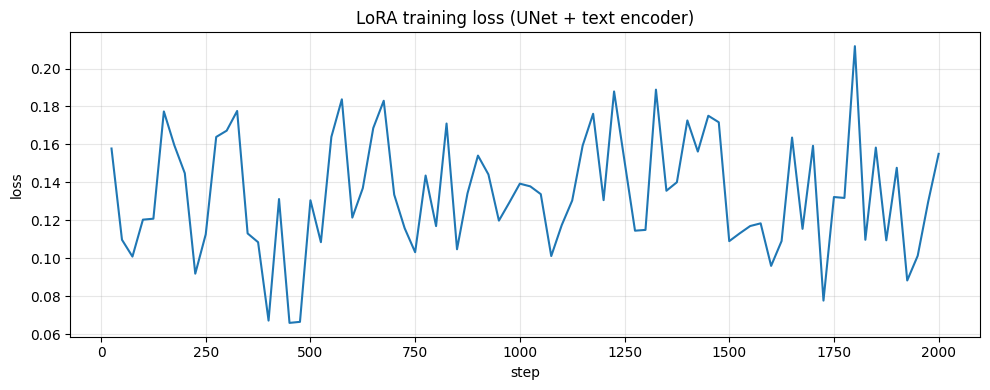

In [9]:
if Path(history_path).exists():
    df = pd.read_csv(history_path)
    plt.figure(figsize=(10, 4))
    plt.plot(df['step'], df['loss'])
    plt.xlabel('step'); plt.ylabel('loss'); plt.title('LoRA training loss (UNet + text encoder)')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. Сборка пайплайна с обоими LoRA

In [10]:
del unet, text_encoder, vae
torch.cuda.empty_cache()

pipe = StableDiffusionPipeline.from_pretrained(BASE_MODEL, torch_dtype=torch.float16,
                                                safety_checker=None, requires_safety_checker=False)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=True)

from peft import LoraConfig as PeftLoraConfig
from safetensors.torch import load_file

u_cfg = PeftLoraConfig(r=LORA_RANK, lora_alpha=LORA_RANK,
                       target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
                       lora_dropout=0.0, bias='none')
t_cfg = PeftLoraConfig(r=LORA_RANK, lora_alpha=LORA_RANK,
                       target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj'],
                       lora_dropout=0.0, bias='none')
pipe.unet = get_peft_model(pipe.unet, u_cfg)
pipe.text_encoder = get_peft_model(pipe.text_encoder, t_cfg)
u_sd = load_file(str(unet_state_path))
t_sd = load_file(str(text_state_path))
pipe.unet.load_state_dict(u_sd, strict=False)
pipe.text_encoder.load_state_dict(t_sd, strict=False)
pipe.unet = pipe.unet.to(device, dtype=torch.float16).eval()
pipe.text_encoder = pipe.text_encoder.to(device, dtype=torch.float16).eval()
print('pipeline ready with UNet+text LoRA')

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

pipeline ready with UNet+text LoRA


## 7. Генерация в 6 стилях

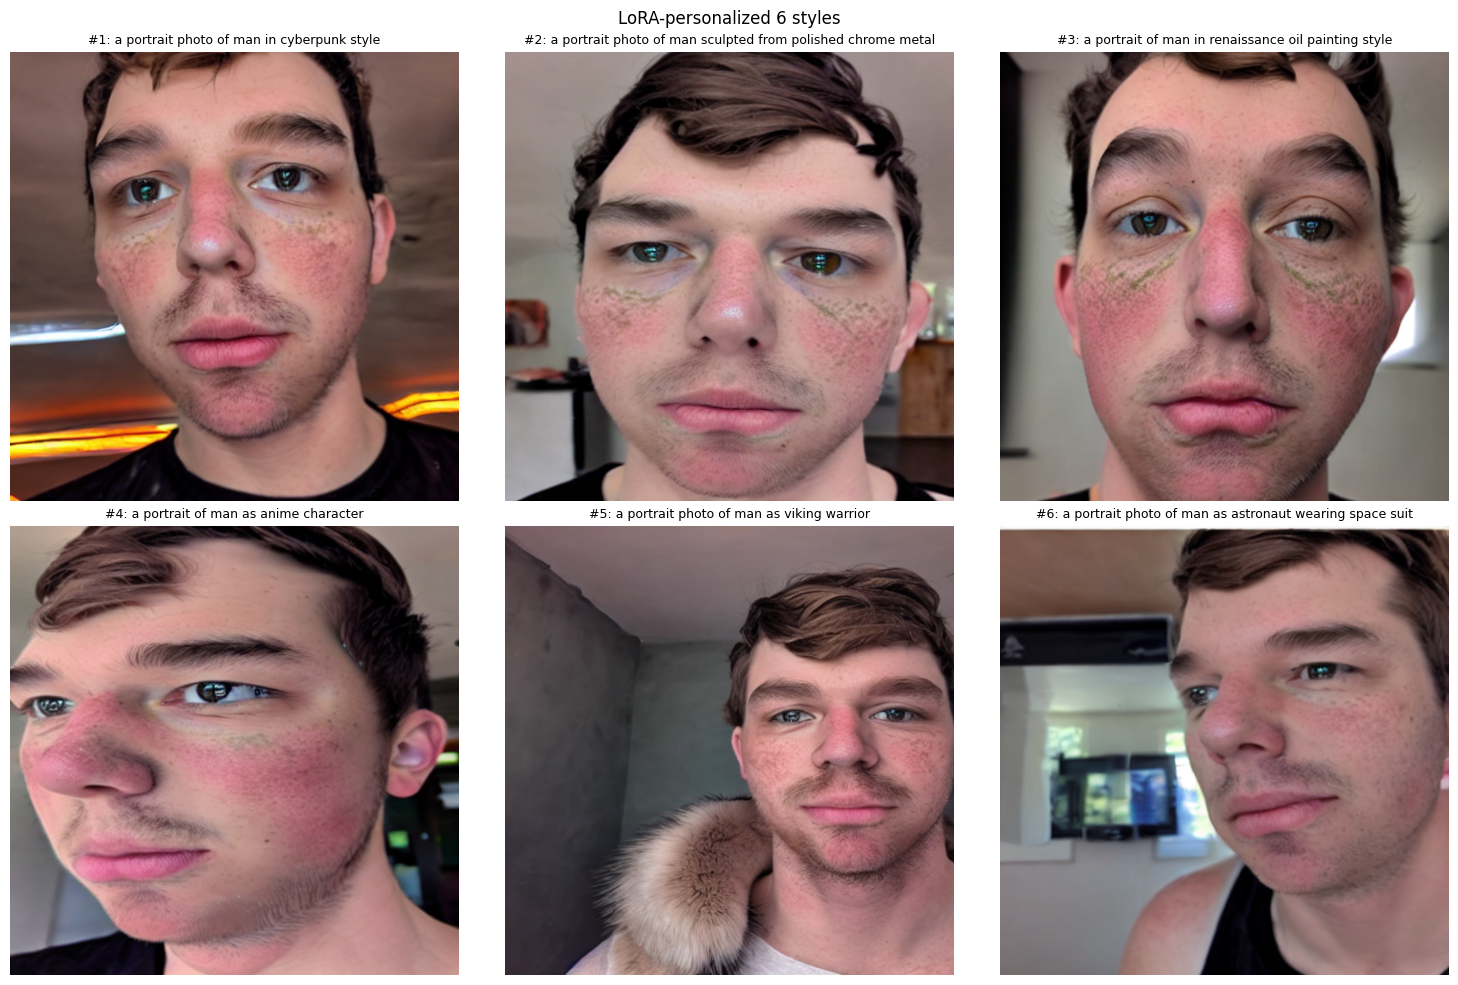

In [11]:
STYLE_PROMPTS = [
    f'a portrait photo of {INSTANCE_TOKEN} {GENDER} in cyberpunk style, neon lights, futuristic city, glowing reflections on face, looking at camera, ultra detailed, 8k',
    f'a portrait photo of {INSTANCE_TOKEN} {GENDER} sculpted from polished chrome metal, reflective surface, looking at camera, studio lighting',
    f'a portrait of {INSTANCE_TOKEN} {GENDER} in renaissance oil painting style, baroque background, dramatic lighting, face in focus',
    f'a portrait of {INSTANCE_TOKEN} {GENDER} as anime character, studio ghibli style, vibrant colors, face in focus',
    f'a portrait photo of {INSTANCE_TOKEN} {GENDER} as viking warrior, snowy mountain background, fur cloak, looking at camera, epic fantasy',
    f'a portrait photo of {INSTANCE_TOKEN} {GENDER} as astronaut wearing space suit, helmet, looking at camera, photography',
]

style_results = []
g = torch.Generator(device=device).manual_seed(SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, prompt in enumerate(STYLE_PROMPTS):
    out = pipe(prompt, num_inference_steps=INFERENCE_STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    out_path = SAMPLES_DIR / f'style_{i+1:02d}.png'
    out.save(out_path)
    style_results.append({'index': i+1, 'prompt': prompt, 'file': str(out_path)})
    ax = axes[i//3, i%3]
    ax.imshow(out); ax.axis('off')
    short = prompt.split(',')[0].replace(f'{INSTANCE_TOKEN} ', '')
    ax.set_title(f'#{i+1}: {short}', fontsize=9)
plt.suptitle('LoRA-personalized 6 styles')
plt.tight_layout(); plt.show()

## 8. Хайлайт-кадр

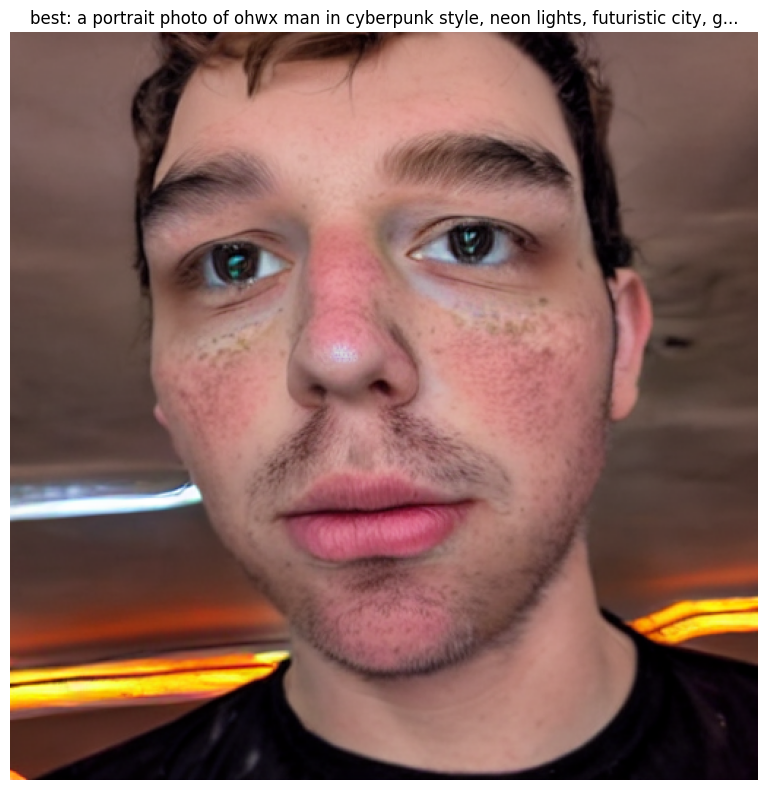

In [12]:
best = Image.open(SAMPLES_DIR / 'style_01.png')
plt.figure(figsize=(8, 8))
plt.imshow(best); plt.axis('off')
plt.title(f'best: {STYLE_PROMPTS[0][:80]}...')
plt.tight_layout(); plt.show()

## 9. forest / city / beach

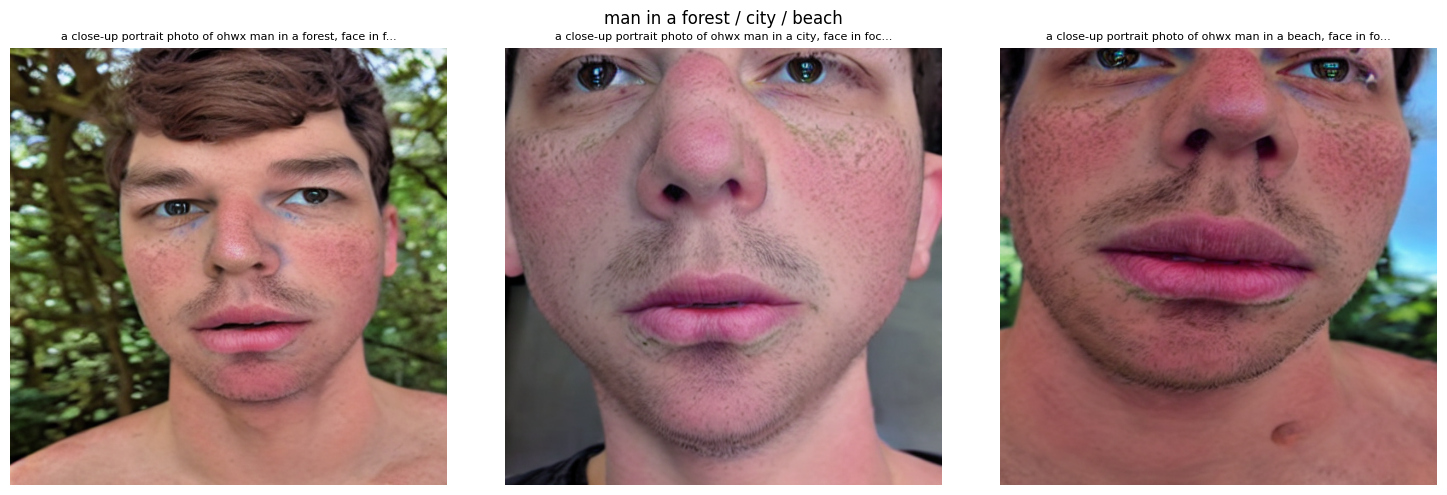

In [13]:
ENV_PROMPTS = [
    f'a close-up portrait photo of {INSTANCE_TOKEN} {GENDER} in a forest, face in focus, looking at camera, high quality, realism',
    f'a close-up portrait photo of {INSTANCE_TOKEN} {GENDER} in a city, face in focus, looking at camera, high quality, realism',
    f'a close-up portrait photo of {INSTANCE_TOKEN} {GENDER} in a beach, face in focus, looking at camera, high quality, realism',
]

env_results = []
g = torch.Generator(device=device).manual_seed(SEED + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, prompt in enumerate(ENV_PROMPTS):
    out = pipe(prompt, num_inference_steps=INFERENCE_STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    out_path = SAMPLES_DIR / f'env_{i+1:02d}.png'
    out.save(out_path)
    env_results.append({'index': i+1, 'prompt': prompt, 'file': str(out_path)})
    axes[i].imshow(out); axes[i].axis('off')
    axes[i].set_title(prompt[:60] + '...', fontsize=8)
plt.suptitle(f'{GENDER} in a forest / city / beach')
plt.tight_layout(); plt.show()

## 10. results.json

In [14]:
results = {
    'task': 'personalized_text_to_image_StableDiffusion',
    'base_model': BASE_MODEL,
    'method': 'LoRA fine-tuning on UNet+text encoder, MTCNN tight face-crop preprocessing',
    'instance_token': INSTANCE_TOKEN,
    'gender': GENDER,
    'instance_prompt': INSTANCE_PROMPT,
    'lora': {
        'rank': LORA_RANK,
        'unet_target_modules': ['to_q', 'to_k', 'to_v', 'to_out.0'],
        'text_target_modules': ['q_proj', 'k_proj', 'v_proj', 'out_proj'],
        'optimizer': 'AdamW8bit (bitsandbytes)',
        'lr_unet': LR_UNET,
        'lr_text': LR_TEXT,
        'max_train_steps': MAX_TRAIN_STEPS,
        'grad_accum': GRAD_ACCUM,
        'batch_size': BATCH,
    },
    'inference': {
        'resolution': RESOLUTION,
        'num_inference_steps': INFERENCE_STEPS,
        'guidance_scale': GUIDANCE,
        'negative_prompt': None,
        'use_img2img': False,
    },
    'reference_photos': [p.name for p in me_imgs],
    'face_crops_used': len(face_files),
    'style_outputs': style_results,
    'env_outputs': env_results,
}
RESULTS_PATH.write_text(json.dumps(results, indent=2, ensure_ascii=False))
print(json.dumps({k: results[k] for k in ['base_model', 'method', 'instance_prompt', 'lora', 'inference']}, indent=2, ensure_ascii=False))

{
  "base_model": "runwayml/stable-diffusion-v1-5",
  "method": "LoRA fine-tuning on UNet+text encoder, MTCNN tight face-crop preprocessing",
  "instance_prompt": "a close-up portrait photo of ohwx man",
  "lora": {
    "rank": 32,
    "unet_target_modules": [
      "to_q",
      "to_k",
      "to_v",
      "to_out.0"
    ],
    "text_target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
      "out_proj"
    ],
    "optimizer": "AdamW8bit (bitsandbytes)",
    "lr_unet": 0.0001,
    "lr_text": 5e-05,
    "max_train_steps": 2000,
    "grad_accum": 1,
    "batch_size": 1
  },
  "inference": {
    "resolution": 512,
    "num_inference_steps": 35,
    "guidance_scale": 7.0,
    "negative_prompt": null,
    "use_img2img": false
  }
}
